# Questão 1

Faça um código em Python que leia o arquivo house-price.txt e realize o split em conjuntos de treino/teste com as seguintes proporções:

a) 90/10
b) 80/20
c) 75/25
d) 70/30
e) 60/40

Plote um gráfico de scatter plot colorindo o conjunto de treinamento e o de teste em cada divisão.
Você observou algum padrão nas figuras geradas?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
data = pd.read_csv("house-price.txt", header=None, names=["Tamanho", "Quartos", "Preço"])
data.head()

,Tamanho,Quartos,Preço
0,2104,3,399900
1,1600,3,329900
2,2400,3,369000
3,1416,2,232000
4,3000,4,539900


In [3]:
def plot_split(X_train, X_test, y_train, y_test, proporcao):
    plt.figure(figsize=(7,5))
    plt.scatter(X_train.iloc[:,0], y_train, color='blue', label='Treino', alpha=0.6)
    plt.scatter(X_test.iloc[:,0], y_test, color='red', label='Teste', alpha=0.6)
    plt.title(f"Split {proporcao}% Treino / {100 - proporcao}% Teste")
    plt.xlabel("Tamanho (sqft)")
    plt.ylabel("Preço ($)")
    plt.legend()
    plt.grid(True)
    plt.show()

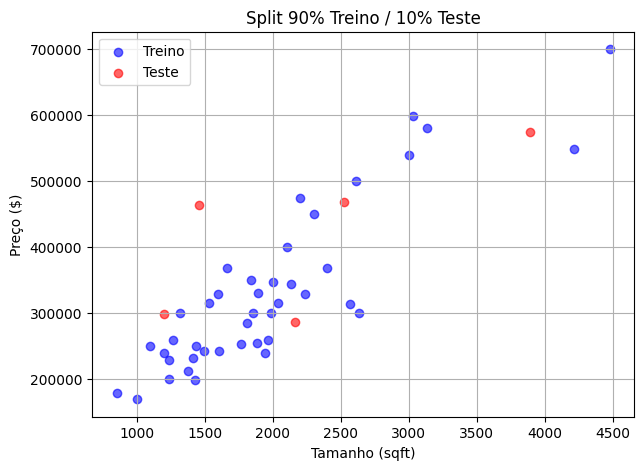

In [4]:
X = data[["Tamanho", "Quartos"]]
y = data["Preço"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=42)
plot_split(X_train, X_test, y_train, y_test, 90)

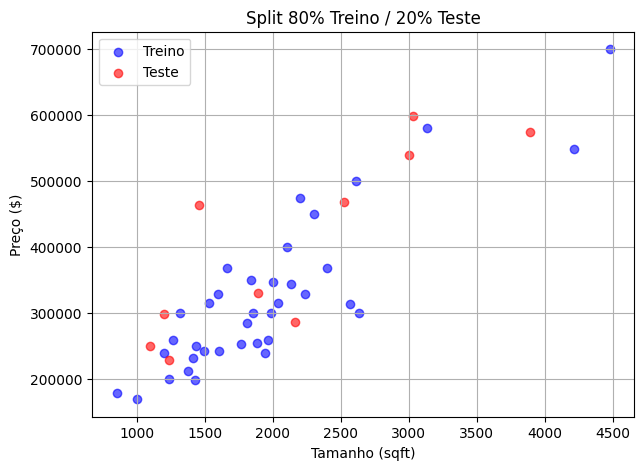

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
plot_split(X_train, X_test, y_train, y_test, 80)

# Questão 1

Faça um código em Python que leia o arquivo house-price.txt e realize o split em conjuntos de treino/teste com as seguintes proporções:

a) 90/10
b) 80/20
c) 75/25
d) 70/30
e) 60/40

Plote um gráfico de scatter plot colorindo o conjunto de treinamento e o de teste em cada divisão.
Você observou algum padrão nas figuras geradas?

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [7]:
data = pd.read_csv("house-price.txt", header=None, names=["Tamanho", "Quartos", "Preço"])
data.head()

,Tamanho,Quartos,Preço
0,2104,3,399900
1,1600,3,329900
2,2400,3,369000
3,1416,2,232000
4,3000,4,539900


In [8]:
def plot_split(X_train, X_test, y_train, y_test, proporcao):
    plt.figure(figsize=(7,5))
    plt.scatter(X_train.iloc[:,0], y_train, color='blue', label='Treino', alpha=0.6)
    plt.scatter(X_test.iloc[:,0], y_test, color='red', label='Teste', alpha=0.6)
    plt.title(f"Split {proporcao}% Treino / {100 - proporcao}% Teste")
    plt.xlabel("Tamanho (sqft)")
    plt.ylabel("Preço ($)")
    plt.legend()
    plt.grid(True)
    plt.show()

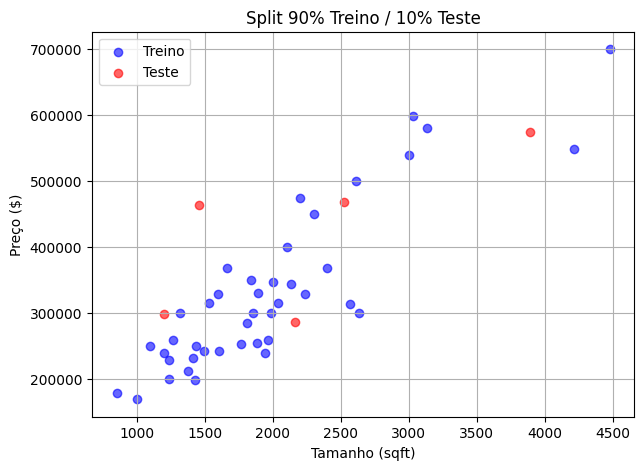

In [9]:
X = data[["Tamanho", "Quartos"]]
y = data["Preço"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=42)
plot_split(X_train, X_test, y_train, y_test, 90)

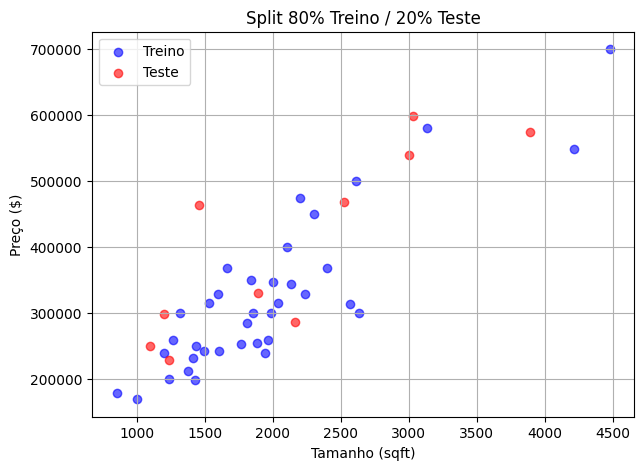

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
plot_split(X_train, X_test, y_train, y_test, 80)

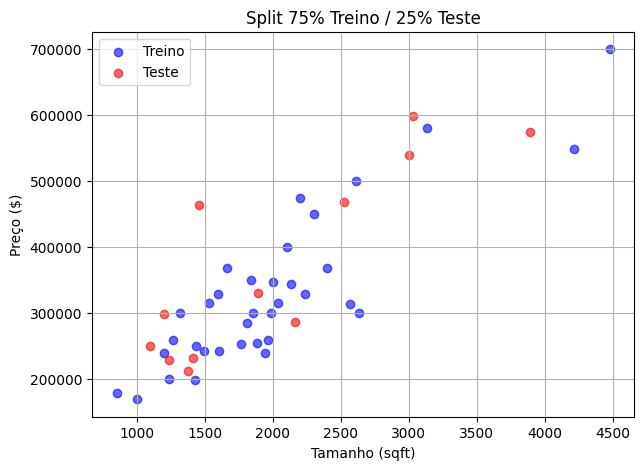

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
plot_split(X_train, X_test, y_train, y_test, 75)

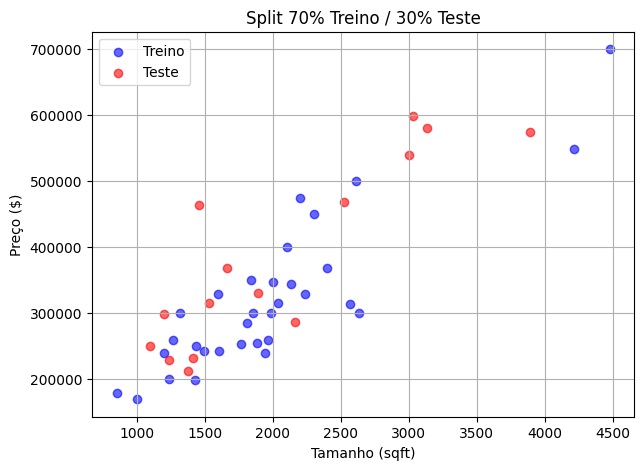

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)
plot_split(X_train, X_test, y_train, y_test, 70)

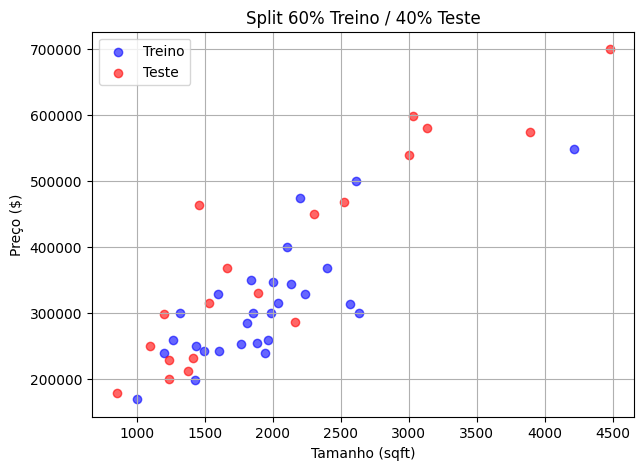

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.40, random_state=42)
plot_split(X_train, X_test, y_train, y_test, 60)

As figuras mostram distribuições aleatórias semelhantes entre treino e teste; a única diferença observável é a quantidade relativa de pontos em cada conjunto.

# Questão 2

Escreva um script em Python usando o Scikit-Learn para treinar e estimar com a regressão linear sobre a base de dados Diabetes Dataset.

A base contém 11 colunas, em que as 10 primeiras são features monitoradas, e a 11ª mostra o progresso da doença em um ano.

a) Os dados estão normalizados? Precisam ser normalizados? Precisam ser de-normalizados?
Aplique as técnicas que achar necessário e explique o que foi feito com as suas próprias palavras.

b) Faça um gráfico de dispersão, em que no eixo horizontal constam os valores reais, e no eixo vertical os valores estimados.

In [14]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [15]:
diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [18]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R²:", r2)

MSE: 2900.193628493482
R²: 0.4526027629719195


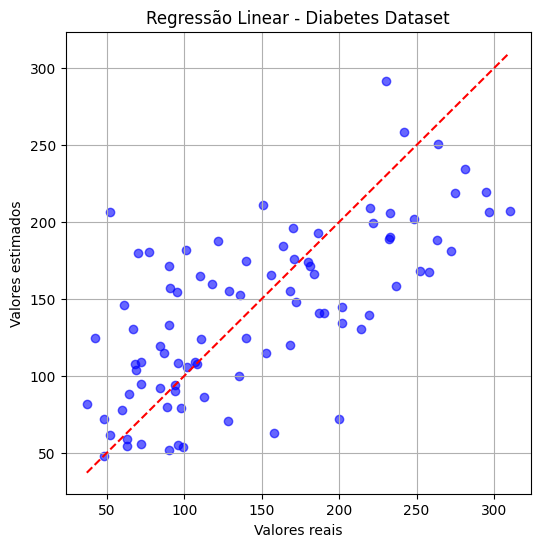

In [19]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Valores reais")
plt.ylabel("Valores estimados")
plt.title("Regressão Linear - Diabetes Dataset")
plt.grid(True)
plt.show()

Os dados do Diabetes Dataset já estão normalizados (com média zero e variância unitária),
o que é indicado pela própria documentação do Scikit-Learn. Portanto, não é necessário
normalizar ou de-normalizar novamente. Essa normalização garante que todas as features
tenham a mesma escala, o que melhora a estabilidade numérica da regressão linear.

# Questão 3

Escreva um script em Python usando o Scikit-Learn para treinar e classificar com a regressão logística sobre a base de dados Wine Dataset.

A base contém 13 colunas, em que as 12 primeiras são features preditivas, e a 13ª coluna contém a definição da classe.

Os dados estão normalizados? Precisam ser normalizados? Precisam ser de-normalizados?
Aplique as técnicas que achar necessário e explique o que foi feito com as suas próprias palavras.

In [20]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns

In [21]:
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [25]:
y_pred = model.predict(X_test_scaled)

print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred))

Acurácia: 0.9722222222222222

Relatório de Classificação:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.97        14
           2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



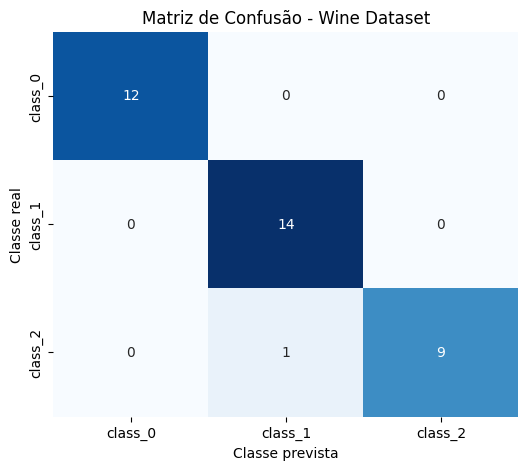

In [26]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")
plt.title("Matriz de Confusão - Wine Dataset")
plt.show()

O Wine Dataset não é normalizado originalmente. As variáveis possuem escalas muito diferentes
(como álcool, magnésio, fenol, etc.). Isso pode prejudicar a regressão logística, que é sensível à escala
dos atributos. Por isso, foi aplicado o StandardScaler para normalizar os dados (média 0, desvio padrão 1).
Não é necessário normalizar, pois o objetivo é apenas treinar e avaliar o modelo.